# Task: Goldfish-to-shark adversarial attack

You are given a set of images that are classified by a model trained on Imagenet as a goldfish (class `GOLDFISH_LABEL=1`).<br>
Your task is to compute a strip of pixels of height 10, which, when pasted into the top 10 rows of *each* of the original images, makes the model classify each image as a shark (class `SHARK_LABEL=2`) with returned probability at least 0.5.

This should run under 2 minutes on CPU.

## Data

Below you can find a piece of code that download a zipfile and displays the images.

In [57]:
import PIL.Image
import matplotlib.pyplot as plt
import numpy as np
import requests
import torch
import zipfile
from io import BytesIO
from PIL import Image
from torch import Tensor
from torchvision.transforms import v2
from typing import cast
import torch.nn as nn

from timm.data.constants import IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD


torch.use_deterministic_algorithms(True)


def get_images(
    url: str = "https://www.mimuw.edu.pl/~cygan/goldfish.zip",
    target_height: int = 100,
    target_width: int = 100,
) -> list[Tensor]:
    """Return five images as tensors of shape (C=3, H=target_height, W=target_width), 0..1 values."""
    request = requests.get(url)
    images = []
    with zipfile.ZipFile(BytesIO(request.content)) as z:
        for filename in z.namelist():
            if not filename.lower().endswith((".jpg", ".jpeg")):
                continue
            with z.open(filename) as f:
                images.append(Image.open(f).convert("RGB"))

    transformations = v2.Compose([
        v2.Resize(size=(target_height, target_width)),
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),  # scale to 0..1
    ])
    return [cast(Tensor, transformations(img)) for img in images]


def tensor_to_pil(image: Tensor) -> PIL.Image.Image:
    """Convert image tensor of shape (C, H, W), values 0..1, to PIL Image."""
    C, H, W = image.shape
    image = image.detach().permute(1, 2, 0).clone()  # to (H, W, C)
    img = PIL.Image.fromarray((image.numpy() * 255).astype(np.uint8))
    return img


normalize_colors = v2.Normalize(
    mean=IMAGENET_DEFAULT_MEAN,
    std=IMAGENET_DEFAULT_STD
)

torch.Size([3, 100, 100])


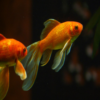

torch.Size([3, 100, 100])


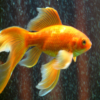

torch.Size([3, 100, 100])


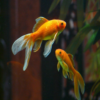

torch.Size([3, 100, 100])


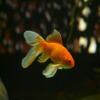

torch.Size([3, 100, 100])


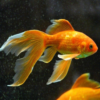

In [58]:
images = get_images()
for img in images:
    print(img.shape)
    display(tensor_to_pil(img))

## Model

We will be using the `mobilenet_v2` model, trained to do classification on the Imagenet dataset.
For this task, the model is a black-box: you do not have to know the details of the model's architecture.
In particular the model's weights should not be changed.

In [59]:
import torch.nn
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

DEFAULT_DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"

def get_model(device: str = DEFAULT_DEVICE) -> torch.nn.Module:
    """Load a pretrained MobileNetV2 model.

    Input: normalized (not 0..1) images of shape (B, C, H, W),
    Output: logits (not probabilities or logprobs) of shape (B, num_classes=1000,).
    """
    model = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)
    model.to(torch.device(device))
    model.eval()
    model.requires_grad_(False)
    return model

GOLDFISH_LABEL = MobileNet_V2_Weights.IMAGENET1K_V1.meta["categories"].index("goldfish")
SHARK_LABEL = MobileNet_V2_Weights.IMAGENET1K_V1.meta["categories"].index("great white shark")
GOLDFISH_LABEL, SHARK_LABEL

(1, 2)

In [60]:
model = get_model()
model

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

## Evaluation

Below is a piece of code for:
* pasting the strip and running model inference on a normalized image;
* evaluating how well a strip performs, for this attack task.

In [76]:
STRIP_HEIGHT = 10

def evaluate_strip(model: torch.nn.Module, images: list[Tensor], strip: Tensor) -> None:
    """
    Print goldfish and shark probabilities for each image with the given strip pasted on top.

    Args:
    - model: the classification model.
    - images: list of tensors of shape (3, H, W), values 0..1
    - strip: tensor of shape (3, STRIP_HEIGHT, W), values 0..1.
    """
    C, H, W = images[0].shape
    assert strip.shape == (C, STRIP_HEIGHT, W)
    assert strip.min() >= 0 and strip.max() <= 1, f"Strip should be 0..1, got {strip.min()=}, {strip.max()=}."

    device = next(model.parameters()).device

    for img in images:
        img = img.clone().to(device)
        img[:, :strip.shape[1], :] = strip.to(device)
        img = normalize_colors(img)
        logits = model(img.unsqueeze(0)).squeeze(0)  # Shape (num_classes=1000,)
        probabilities = torch.nn.functional.softmax(logits, dim=-1)
        p_goldfish, p_shark = probabilities[[GOLDFISH_LABEL, SHARK_LABEL]]
        print(f'Probabilities assigned to: goldfish={p_goldfish:.5%}, shark={p_shark:.5%}.')


zero_strip = torch.zeros(3, STRIP_HEIGHT, images[0].shape[2])
evaluate_strip(model, images, zero_strip)

Probabilities assigned to: goldfish=99.91120%, shark=0.00000%.
Probabilities assigned to: goldfish=99.96259%, shark=0.00000%.
Probabilities assigned to: goldfish=95.45314%, shark=0.00000%.
Probabilities assigned to: goldfish=95.52149%, shark=0.00000%.
Probabilities assigned to: goldfish=99.78421%, shark=0.00000%.


## TO IMPLEMENT

Here you have to implement the function that finds the strip.


In [77]:
def calculate_strip(model: torch.nn.Module, images: list[Tensor], seed: int = 1, quiet: bool = False) -> Tensor:
    device = next(model.parameters()).device
    torch.manual_seed(seed)

    # Number of optimization steps (you can change this)
    max_iters = 400

    # Basic setup
    assert len(images) > 0, "Need at least one image"
    C, H, W = images[0].shape
    assert C == 3, "Images must have 3 channels"

    h_strip = STRIP_HEIGHT  # should be defined globally (10)
    strip = torch.zeros(3, h_strip, W, device=device, requires_grad=True)

    optimizer = torch.optim.Adam([strip], lr=0.1)
    target_label = SHARK_LABEL  # defined earlier in notebook

    for it in range(max_iters):
        optimizer.zero_grad()
        loss = 0.0

        # Accumulate loss across all images
        for img in images:
            img = img.clone().to(device)
            img[:, :h_strip, :] = strip
            img_norm = normalize_colors(img)  # normalize before model
            logits = model(img_norm.unsqueeze(0)).squeeze(0)
            loss = loss + (-logits[target_label])  # maximize shark logit

        loss = loss / len(images)
        """
        target_logits = []
        for img in images:
          img = img.clone().to(device)
          img[:, :h_strip, :] = strip
          img_norm = normalize_colors(img)
          logits = model(img_norm.unsqueeze(0)).squeeze(0)
          target_logits.append(logits[target_label])

        target_logits = torch.stack(target_logits)
        loss = -torch.min(target_logits)
        """

        target_logprobs = []
        for img in images:
            img = img.clone().to(device)
            img[:, :h_strip, :] = strip
            img_norm = normalize_colors(img)
            logits = model(img_norm.unsqueeze(0)).squeeze(0)
            probs = torch.nn.functional.softmax(logits, dim=-1)
            target_logprobs.append(torch.log(probs[target_label]))

        target_logprobs = torch.stack(target_logprobs)
        loss = -torch.min(target_logprobs)  # maximize log-prob of worst-case image
        # loss = -torch.mean(target_logprobs)  # maximize log-prob of worst-case image

        loss.backward()
        optimizer.step()

        with torch.no_grad():
            strip.clamp_(0.0, 1.0)

        # Log progress
        if not quiet and (it % 50 == 0 or it == max_iters - 1):
            avg_p = 0.0
            with torch.no_grad():
                for img in images:
                    img2 = img.clone().to(device)
                    img2[:, :h_strip, :] = strip
                    logits = model(normalize_colors(img2).unsqueeze(0)).squeeze(0)
                    probs = torch.nn.functional.softmax(logits, dim=-1)
                    avg_p += probs[target_label]
                avg_p = avg_p / len(images)
            print(f"Iter {it:4d}: avg shark prob = {avg_p:.5%}")

    return strip.detach().cpu().clamp(0.0, 1.0)

In [78]:
your_strip = calculate_strip(model, images)
print(your_strip.shape)


Iter    0: avg shark prob = 0.00000%
Iter   50: avg shark prob = 0.00017%
Iter  100: avg shark prob = 0.00627%
Iter  150: avg shark prob = 1.01085%
Iter  200: avg shark prob = 4.37011%
Iter  250: avg shark prob = 62.98090%
Iter  300: avg shark prob = 95.56297%
Iter  350: avg shark prob = 97.40009%
Iter  399: avg shark prob = 97.85496%
torch.Size([3, 10, 100])


In [80]:
evaluate_strip(model, images, your_strip)

Probabilities assigned to: goldfish=0.08440%, shark=98.11211%.
Probabilities assigned to: goldfish=0.70039%, shark=97.79654%.
Probabilities assigned to: goldfish=0.00947%, shark=97.82609%.
Probabilities assigned to: goldfish=0.01534%, shark=97.74495%.
Probabilities assigned to: goldfish=0.73632%, shark=97.79512%.


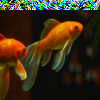

Probabilities assigned to: goldfish=0.08440%, shark=98.11211%.


In [81]:
# Pick an image to inspect
img = images[0].clone()  # avoid modifying the original
img[:, 0:10, :] = your_strip
display(tensor_to_pil(img))

# Normalize the image exactly as in training
img_norm = normalize_colors(img)
logits = model(img_norm.unsqueeze(0)).squeeze(0)

# Convert to probabilities
probabilities = torch.nn.functional.softmax(logits, dim=-1)
p_goldfish, p_shark = probabilities[[GOLDFISH_LABEL, SHARK_LABEL]]
print(f'Probabilities assigned to: goldfish={p_goldfish:.5%}, shark={p_shark:.5%}.')